# 🧠 FoodBridge AI - LSTM Hunger Hotspot Prediction

This notebook trains an LSTM (Long Short-Term Memory) neural network to predict food demand for NGOs over a 7-day forecast horizon.

## Model Architecture
- **Input**: 21 days of historical data with 23 features
- **LSTM Layers**: 64 → 32 units with dropout
- **Output**: 7-day demand forecast
- **Training**: Adam optimizer, MSE loss, early stopping

## 1. Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: mps
PyTorch version: 2.10.0


## 2. Configuration

In [2]:
# NGO Configurations
@dataclass
class NGOConfig:
    name: str
    base_demand: float
    volatility: float
    weekly_pattern: List[float]
    trend: float

NGO_CONFIGS = {
    'NGO_1': NGOConfig('Community Food Bank', 150, 0.15, [0.85, 1.0, 1.1, 1.05, 1.0, 0.9, 0.8], 0.001),
    'NGO_2': NGOConfig('Urban Shelter Network', 200, 0.25, [0.9, 0.95, 1.0, 1.1, 1.15, 1.1, 0.95], 0.002),
    'NGO_3': NGOConfig('Children Nutrition Center', 80, 0.10, [1.2, 1.15, 1.1, 1.05, 1.0, 0.7, 0.6], 0.0),
    'NGO_4': NGOConfig('Senior Care Foundation', 120, 0.12, [0.95, 1.0, 1.0, 1.0, 1.0, 0.95, 0.9], -0.0005),
    'NGO_5': NGOConfig('Emergency Relief Hub', 100, 0.30, [0.8, 0.9, 1.0, 1.1, 1.2, 1.1, 1.0], 0.003),
}

# Model Configuration
SEQUENCE_LENGTH = 21  # Input window (3 weeks)
FORECAST_HORIZON = 7  # Output window (1 week)
LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 32
DENSE_UNITS = 16
DROPOUT_RATE = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 15

# Data Configuration
START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2025, 12, 31)
VALIDATION_SPLIT = 0.2
TEST_SPLIT = 0.1

print("Configuration loaded successfully!")

Configuration loaded successfully!


## 3. Generate Synthetic Dataset

We create realistic food demand data with:
- **Weekly patterns**: Different demand on different days
- **Seasonal variation**: Monthly fluctuations
- **Long-term trends**: Gradual changes over time
- **Random noise**: Natural variation
- **Special events**: Occasional demand spikes

In [3]:
def generate_synthetic_data(start_date: datetime, end_date: datetime) -> pd.DataFrame:
    """Generate synthetic food demand data for all NGOs."""
    
    # Seasonal factors by month (Indian context)
    SEASONAL_FACTORS = {
        1: 1.05, 2: 1.0, 3: 0.95, 4: 0.90, 5: 0.85, 6: 0.90,
        7: 1.0, 8: 1.05, 9: 1.10, 10: 1.15, 11: 1.10, 12: 1.05
    }
    
    all_data = []
    date_range = pd.date_range(start=start_date, end=end_date, freq='D')
    
    for ngo_id, config in NGO_CONFIGS.items():
        for i, date in enumerate(date_range):
            day_of_week = date.weekday()
            month = date.month
            
            # Get factors
            weekly_factor = config.weekly_pattern[day_of_week]
            seasonal_factor = SEASONAL_FACTORS[month]
            
            # Calculate trend factor (compound growth/decay)
            days_elapsed = (date - start_date).days
            trend_factor = (1 + config.trend) ** days_elapsed
            
            # Random noise
            noise = np.random.normal(0, config.volatility)
            
            # Special events (5% chance of a spike)
            event_multiplier = 1.0
            has_event = np.random.random() < 0.05
            if has_event:
                event_multiplier = np.random.uniform(1.2, 1.5)
            
            # Calculate demand
            demand = (
                config.base_demand * 
                weekly_factor * 
                seasonal_factor * 
                trend_factor * 
                (1 + noise) * 
                event_multiplier
            )
            demand = max(10, demand)  # Minimum demand
            
            # Calculate other features
            num_requests = max(1, int(demand / np.random.uniform(8, 15)))
            urgency = np.random.uniform(0.3, 0.9) if demand > config.base_demand else np.random.uniform(0.1, 0.5)
            
            all_data.append({
                'date': date,
                'ngo_id': ngo_id,
                'ngo_name': config.name,
                'total_food_requested': demand,
                'number_of_requests': num_requests,
                'urgency_score': urgency,
                'day_of_week': day_of_week,
                'month': month,
                'is_weekend': 1 if day_of_week >= 5 else 0,
                'seasonal_factor': seasonal_factor,
                'weekly_factor': weekly_factor,
                'has_special_event': 1 if has_event else 0
            })
    
    return pd.DataFrame(all_data)

# Generate data
print("Generating synthetic dataset...")
df = generate_synthetic_data(START_DATE, END_DATE)
print(f"Generated {len(df):,} records for {len(NGO_CONFIGS)} NGOs")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head(10)

Generating synthetic dataset...
Generated 3,655 records for 5 NGOs
Date range: 2024-01-01 to 2025-12-31


,date,ngo_id,ngo_name,total_food_requested,number_of_requests,urgency_score,day_of_week,month,is_weekend,seasonal_factor,weekly_factor,has_special_event
0,2024-01-01,NGO_1,Community Food Bank,143.849641,11,0.162407,0,1,0,1.05,0.85,0
1,2024-01-02,NGO_1,Community Food Bank,154.387739,18,0.819706,1,1,0,1.05,1.00,0
2,2024-01-03,NGO_1,Community Food Bank,320.139606,23,0.427403,2,1,0,1.05,1.10,1
3,2024-01-04,NGO_1,Community Food Bank,184.965968,19,0.482545,3,1,0,1.05,1.05,0
4,2024-01-05,NGO_1,Community Food Bank,96.162219,7,0.155798,4,1,0,1.05,1.00,0
5,2024-01-06,NGO_1,Community Food Bank,162.768643,15,0.573642,5,1,1,1.05,0.90,0
6,2024-01-07,NGO_1,Community Food Bank,114.789255,9,0.118580,6,1,1,1.05,0.80,0
7,2024-01-08,NGO_1,Community Food Bank,146.902188,15,0.126021,0,1,0,1.05,0.85,0
8,2024-01-09,NGO_1,Community Food Bank,144.469576,11,0.276061,1,1,0,1.05,1.00,0
9,2024-01-10,NGO_1,Community Food Bank,199.659577,17,0.320633,2,1,0,1.05,1.10,0


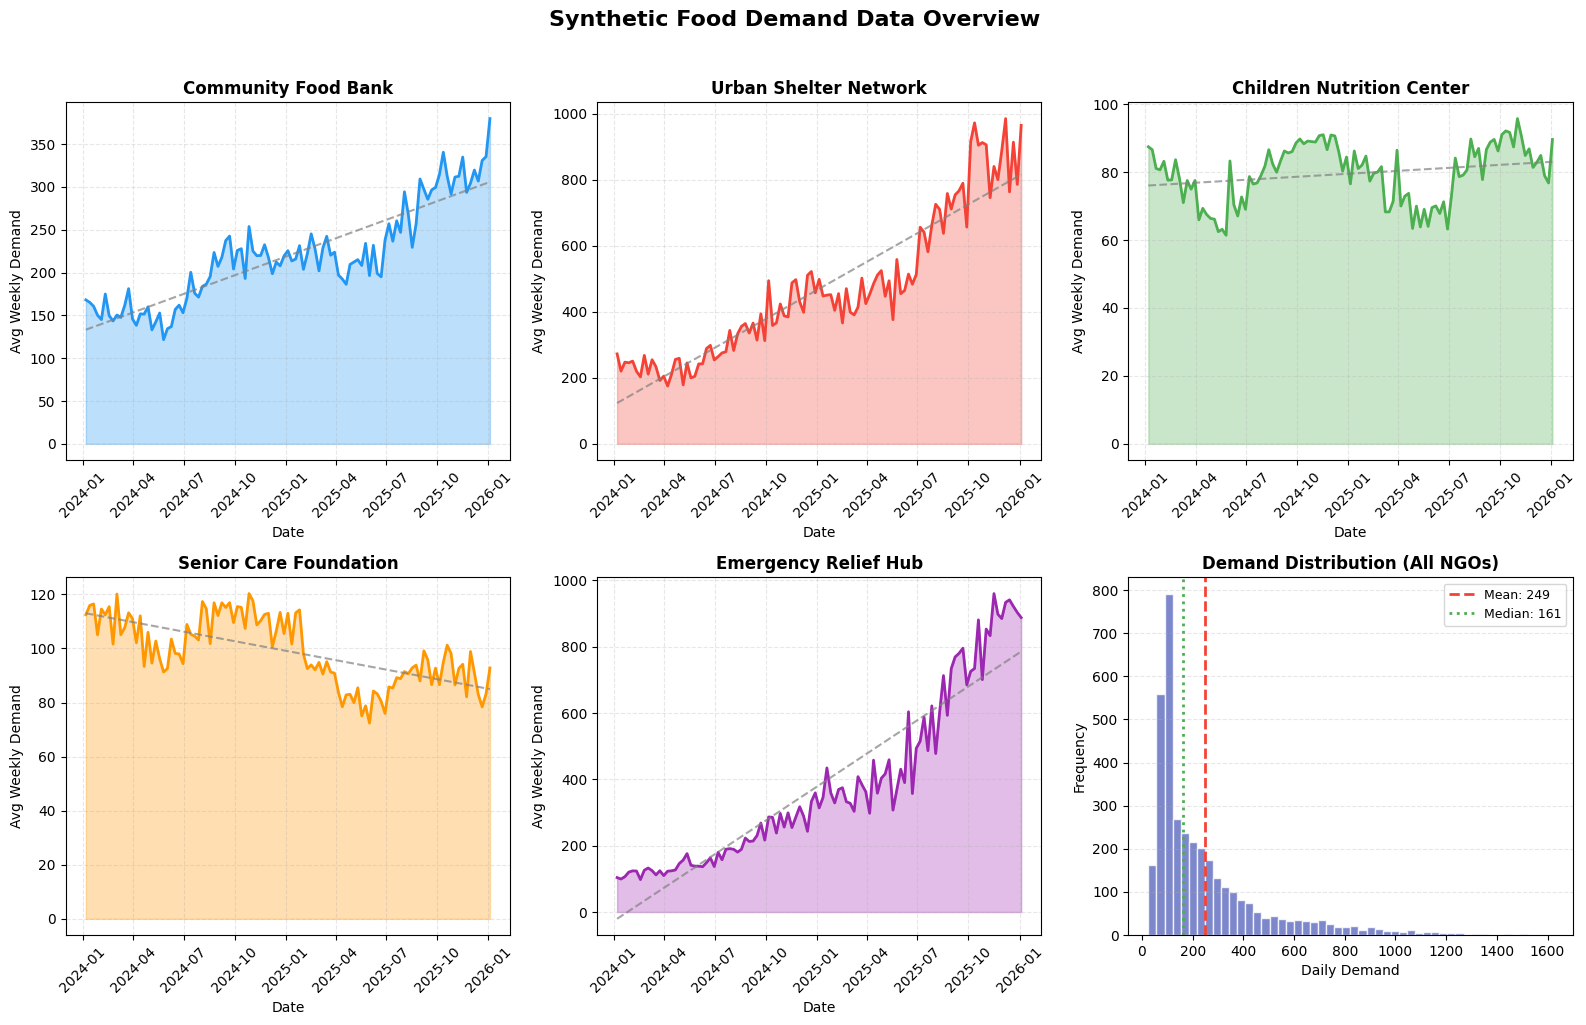

✓ Saved: outputs/synthetic_data_overview.png


In [16]:
# Visualize the generated data with improved styling
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Synthetic Food Demand Data Overview', fontsize=16, fontweight='bold', y=1.02)

# Define colors for each NGO
colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

# Plot demand for each NGO
for idx, (ngo_id, config) in enumerate(NGO_CONFIGS.items()):
    row, col = idx // 3, idx % 3
    ngo_data = df[df['ngo_id'] == ngo_id].copy()
    
    # Resample to weekly for clarity
    weekly = ngo_data.set_index('date')['total_food_requested'].resample('W').mean()
    
    axes[row, col].plot(weekly.index, weekly.values, linewidth=2, color=colors[idx])
    axes[row, col].fill_between(weekly.index, weekly.values, alpha=0.3, color=colors[idx])
    axes[row, col].set_title(f'{config.name}', fontsize=12, fontweight='bold')
    axes[row, col].set_xlabel('Date', fontsize=10)
    axes[row, col].set_ylabel('Avg Weekly Demand', fontsize=10)
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(True, alpha=0.3, linestyle='--')
    
    # Add trend line
    x_numeric = np.arange(len(weekly))
    z = np.polyfit(x_numeric, weekly.values, 1)
    p = np.poly1d(z)
    axes[row, col].plot(weekly.index, p(x_numeric), '--', color='gray', linewidth=1.5, alpha=0.7)

# Use the last subplot for overall distribution
all_demands = df['total_food_requested']
axes[1, 2].hist(all_demands, bins=50, edgecolor='white', alpha=0.8, color='#5C6BC0')
axes[1, 2].set_title('Demand Distribution (All NGOs)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Daily Demand', fontsize=10)
axes[1, 2].set_ylabel('Frequency', fontsize=10)
axes[1, 2].axvline(x=all_demands.mean(), color='#F44336', linestyle='--', linewidth=2, label=f'Mean: {all_demands.mean():.0f}')
axes[1, 2].axvline(x=all_demands.median(), color='#4CAF50', linestyle=':', linewidth=2, label=f'Median: {all_demands.median():.0f}')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('outputs/synthetic_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: outputs/synthetic_data_overview.png")

## 4. Preprocess Data for LSTM

Key preprocessing steps:
1. **Feature Engineering**: One-hot encode day of week and month
2. **Normalization**: StandardScaler for numerical features
3. **Sequence Creation**: Sliding window approach
4. **Temporal Split**: Train → Validation → Test (no random shuffle!)

In [5]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create all features including one-hot encoding."""
    df = df.copy()
    
    # One-hot encode day of week (7 features)
    for i in range(7):
        df[f'dow_{i}'] = (df['day_of_week'] == i).astype(int)
    
    # One-hot encode month (12 features)
    for i in range(1, 13):
        df[f'month_{i}'] = (df['month'] == i).astype(int)
    
    return df

# Create features
df = create_features(df)

# Define feature columns
FEATURE_COLS = [
    'total_food_requested', 'number_of_requests', 'urgency_score',
    'dow_0', 'dow_1', 'dow_2', 'dow_3', 'dow_4', 'dow_5', 'dow_6',
    'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
    'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
    'is_weekend'
]
TARGET_COL = 'total_food_requested'

print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Features: {FEATURE_COLS[:5]}... (showing first 5)")

Feature columns: 23
Features: ['total_food_requested', 'number_of_requests', 'urgency_score', 'dow_0', 'dow_1']... (showing first 5)


In [6]:
class DataPreprocessor:
    """Handle all data preprocessing for LSTM."""
    
    def __init__(self, feature_cols: List[str], target_col: str):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.feature_scaler = StandardScaler()
        self.target_scaler = StandardScaler()
        self.fitted = False
    
    def fit(self, df: pd.DataFrame):
        """Fit scalers on training data."""
        self.feature_scaler.fit(df[self.feature_cols])
        self.target_scaler.fit(df[[self.target_col]])
        self.fitted = True
    
    def transform_features(self, df: pd.DataFrame) -> np.ndarray:
        """Transform features."""
        return self.feature_scaler.transform(df[self.feature_cols])
    
    def transform_target(self, values: np.ndarray) -> np.ndarray:
        """Transform target."""
        return self.target_scaler.transform(values.reshape(-1, 1)).flatten()
    
    def inverse_transform_target(self, values: np.ndarray) -> np.ndarray:
        """Inverse transform target."""
        return self.target_scaler.inverse_transform(values.reshape(-1, 1)).flatten()

def create_sequences(features: np.ndarray, targets: np.ndarray, 
                     seq_len: int, forecast_horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    """Create input-output sequence pairs using sliding window."""
    X, y = [], []
    
    for i in range(len(features) - seq_len - forecast_horizon + 1):
        X.append(features[i:i + seq_len])
        y.append(targets[i + seq_len:i + seq_len + forecast_horizon])
    
    return np.array(X), np.array(y)

# Initialize preprocessor
preprocessor = DataPreprocessor(FEATURE_COLS, TARGET_COL)

# Process data for each NGO and combine
all_X, all_y, all_ngo_ids = [], [], []

for ngo_id in NGO_CONFIGS.keys():
    ngo_data = df[df['ngo_id'] == ngo_id].sort_values('date').reset_index(drop=True)
    
    # Fit preprocessor on first NGO (or use all data)
    if not preprocessor.fitted:
        preprocessor.fit(ngo_data)
    
    # Transform
    features = preprocessor.transform_features(ngo_data)
    targets = preprocessor.transform_target(ngo_data[TARGET_COL].values)
    
    # Create sequences
    X, y = create_sequences(features, targets, SEQUENCE_LENGTH, FORECAST_HORIZON)
    
    all_X.append(X)
    all_y.append(y)
    all_ngo_ids.extend([ngo_id] * len(X))
    
    print(f"{ngo_id}: {len(X)} sequences")

# Combine all NGOs
X_all = np.vstack(all_X)
y_all = np.vstack(all_y)

print(f"\nTotal sequences: {len(X_all)}")
print(f"Input shape: {X_all.shape} (samples, timesteps, features)")
print(f"Output shape: {y_all.shape} (samples, forecast_horizon)")

NGO_1: 704 sequences
NGO_2: 704 sequences
NGO_3: 704 sequences
NGO_4: 704 sequences
NGO_5: 704 sequences

Total sequences: 3520
Input shape: (3520, 21, 23) (samples, timesteps, features)
Output shape: (3520, 7) (samples, forecast_horizon)


In [7]:
# Temporal train/val/test split
n_samples = len(X_all)
train_end = int(n_samples * (1 - VALIDATION_SPLIT - TEST_SPLIT))
val_end = int(n_samples * (1 - TEST_SPLIT))

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ Data ready for training!")

Training set: 2464 samples
Validation set: 704 samples
Test set: 352 samples

✓ Data ready for training!


## 5. Build LSTM Model

Architecture:
```
Input (21 timesteps × 23 features)
    ↓
LSTM Layer 1 (64 units)
    ↓
Dropout (0.2)
    ↓
LSTM Layer 2 (32 units)
    ↓
Dropout (0.2)
    ↓
Dense (16 units, ReLU)
    ↓
Output (7 units - 7-day forecast)
```

In [8]:
class LSTMModel(nn.Module):
    """Stacked LSTM model for food demand forecasting."""
    
    def __init__(self, input_size: int, hidden_size_1: int, hidden_size_2: int,
                 dense_size: int, output_size: int, dropout: float = 0.2):
        super(LSTMModel, self).__init__()
        
        # LSTM layers
        self.lstm1 = nn.LSTM(input_size, hidden_size_1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        
        self.lstm2 = nn.LSTM(hidden_size_1, hidden_size_2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        
        # Dense layers
        self.fc1 = nn.Linear(hidden_size_2, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, output_size)
        
    def forward(self, x):
        # LSTM 1
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.dropout1(lstm_out1)
        
        # LSTM 2
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.dropout2(lstm_out2[:, -1, :])  # Take last timestep
        
        # Dense layers
        out = self.fc1(lstm_out2)
        out = self.relu(out)
        out = self.fc2(out)
        
        return out

# Initialize model
input_size = len(FEATURE_COLS)
model = LSTMModel(
    input_size=input_size,
    hidden_size_1=LSTM_UNITS_1,
    hidden_size_2=LSTM_UNITS_2,
    dense_size=DENSE_UNITS,
    output_size=FORECAST_HORIZON,
    dropout=DROPOUT_RATE
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
LSTMModel(
  (lstm1): LSTM(23, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (lstm2): LSTM(64, 32, batch_first=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=7, bias=True)
)

Total parameters: 35,975
Trainable parameters: 35,975


## 6. Train the LSTM Model

Training with:
- **Optimizer**: Adam with learning rate 0.001
- **Loss**: Mean Squared Error (MSE)
- **Early Stopping**: Patience of 15 epochs
- **Learning Rate Scheduler**: Reduce on plateau

In [9]:
def train_model(model, train_loader, val_loader, epochs, lr, patience):
    """Train the LSTM model with early stopping."""
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_mae': [],
        'val_mae': [],
        'lr': []
    }
    
    # Early stopping
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    print("Starting training...")
    print("-" * 60)
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_losses = []
        train_maes = []
        
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            train_maes.append(torch.mean(torch.abs(outputs - y_batch)).item())
        
        # Validation phase
        model.eval()
        val_losses = []
        val_maes = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_losses.append(loss.item())
                val_maes.append(torch.mean(torch.abs(outputs - y_batch)).item())
        
        # Calculate epoch metrics
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        train_mae = np.mean(train_maes)
        val_mae = np.mean(val_maes)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Store history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)
        history['lr'].append(current_lr)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                  f"Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} | "
                  f"LR: {current_lr:.6f}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\nRestored best model with validation loss: {best_val_loss:.4f}")
    
    return model, history

# Train the model
model, history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, patience=PATIENCE
)

print("\n✓ Training complete!")

Starting training...
------------------------------------------------------------
Epoch   1/100 | Train Loss: 7.4152 | Val Loss: 1.1243 | Train MAE: 1.7875 | Val MAE: 0.8359 | LR: 0.001000
Epoch   5/100 | Train Loss: 1.3518 | Val Loss: 0.5207 | Train MAE: 0.7007 | Val MAE: 0.4442 | LR: 0.001000
Epoch  10/100 | Train Loss: 1.2995 | Val Loss: 0.5260 | Train MAE: 0.6841 | Val MAE: 0.4479 | LR: 0.001000
Epoch  15/100 | Train Loss: 1.2552 | Val Loss: 0.5206 | Train MAE: 0.6682 | Val MAE: 0.4518 | LR: 0.000500
Epoch  20/100 | Train Loss: 1.2038 | Val Loss: 0.5185 | Train MAE: 0.6592 | Val MAE: 0.4580 | LR: 0.000250

Early stopping at epoch 22

Restored best model with validation loss: 0.5185

✓ Training complete!


## 7. Plot Training History

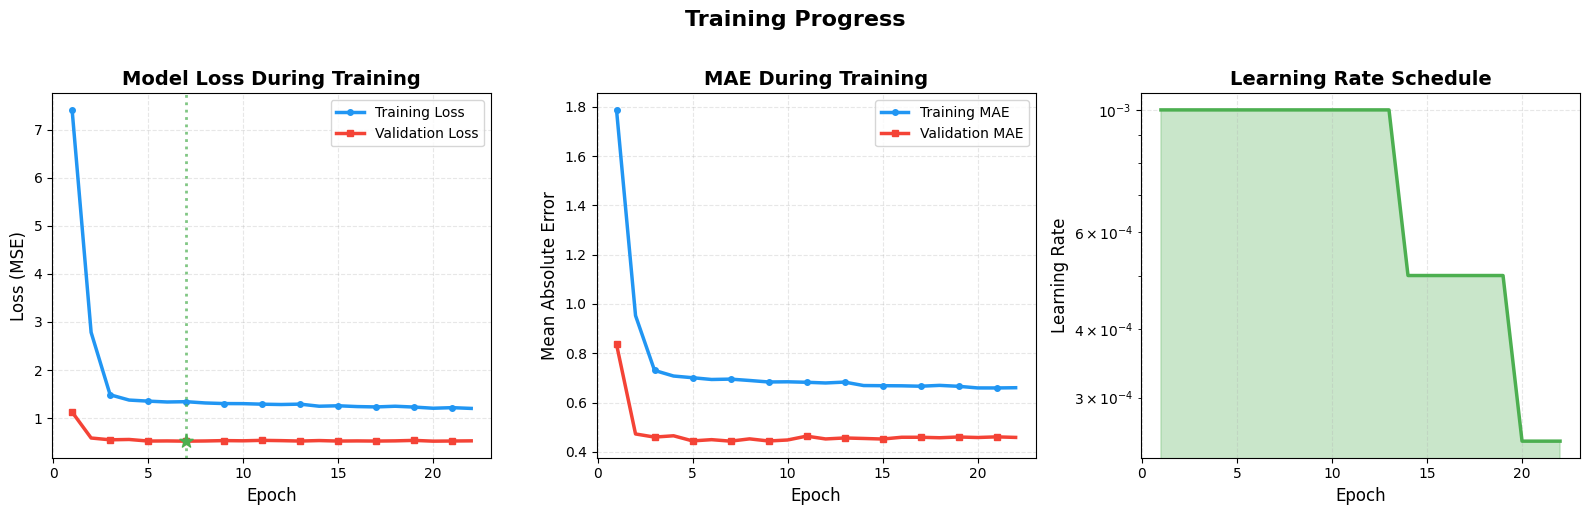

✓ Saved: outputs/training_history.png

Final Metrics:
  Training Loss: 1.2001
  Validation Loss: 0.5251
  Training MAE: 0.6600
  Validation MAE: 0.4584
  Best Epoch: 7


In [17]:
# Training history visualization with improved styling
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Training Progress', fontsize=16, fontweight='bold', y=1.02)

epochs = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs, history['train_loss'], '-', color='#2196F3', label='Training Loss', linewidth=2.5, marker='o', markersize=4, markevery=max(1, len(epochs)//10))
axes[0].plot(epochs, history['val_loss'], '-', color='#F44336', label='Validation Loss', linewidth=2.5, marker='s', markersize=4, markevery=max(1, len(epochs)//10))
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')
# Add best epoch marker
best_epoch = np.argmin(history['val_loss']) + 1
axes[0].axvline(x=best_epoch, color='#4CAF50', linestyle=':', linewidth=2, alpha=0.7, label=f'Best: Epoch {best_epoch}')
axes[0].scatter([best_epoch], [history['val_loss'][best_epoch-1]], s=100, c='#4CAF50', zorder=5, marker='*')

# MAE plot
axes[1].plot(epochs, history['train_mae'], '-', color='#2196F3', label='Training MAE', linewidth=2.5, marker='o', markersize=4, markevery=max(1, len(epochs)//10))
axes[1].plot(epochs, history['val_mae'], '-', color='#F44336', label='Validation MAE', linewidth=2.5, marker='s', markersize=4, markevery=max(1, len(epochs)//10))
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error', fontsize=12)
axes[1].set_title('MAE During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Learning rate plot
axes[2].plot(epochs, history['lr'], '-', color='#4CAF50', label='Learning Rate', linewidth=2.5)
axes[2].fill_between(epochs, 0, history['lr'], alpha=0.3, color='#4CAF50')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('outputs/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: outputs/training_history.png")
print(f"\nFinal Metrics:")
print(f"  Training Loss: {history['train_loss'][-1]:.4f}")
print(f"  Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"  Training MAE: {history['train_mae'][-1]:.4f}")
print(f"  Validation MAE: {history['val_mae'][-1]:.4f}")
print(f"  Best Epoch: {best_epoch}")

## 8. Evaluate Model Performance

In [11]:
# Make predictions on test set
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_t).cpu().numpy()
    y_test_np = y_test_t.cpu().numpy()

# Inverse transform to original scale
y_pred = preprocessor.inverse_transform_target(y_pred_scaled.flatten()).reshape(y_pred_scaled.shape)
y_true = preprocessor.inverse_transform_target(y_test_np.flatten()).reshape(y_test_np.shape)

# Calculate metrics
mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
r2 = r2_score(y_true.flatten(), y_pred.flatten())

# Calculate MAPE (avoiding division by zero)
mask = y_true.flatten() > 0
mape = np.mean(np.abs((y_true.flatten()[mask] - y_pred.flatten()[mask]) / y_true.flatten()[mask])) * 100

print("=" * 50)
print("TEST SET EVALUATION METRICS")
print("=" * 50)
print(f"Mean Squared Error (MSE):     {mse:.4f}")
print(f"Root Mean Squared Error:      {rmse:.4f}")
print(f"Mean Absolute Error (MAE):    {mae:.4f}")
print(f"Mean Absolute % Error (MAPE): {mape:.2f}%")
print(f"R² Score:                     {r2:.4f}")
print("=" * 50)

TEST SET EVALUATION METRICS
Mean Squared Error (MSE):     47759.2969
Root Mean Squared Error:      218.5390
Mean Absolute Error (MAE):    167.1259
Mean Absolute % Error (MAPE): 38.41%
R² Score:                     0.4391


In [12]:
# Per-day performance analysis
print("\nPer-Day Forecast Performance:")
print("-" * 40)
for day in range(FORECAST_HORIZON):
    day_mse = mean_squared_error(y_true[:, day], y_pred[:, day])
    day_mae = mean_absolute_error(y_true[:, day], y_pred[:, day])
    day_r2 = r2_score(y_true[:, day], y_pred[:, day])
    print(f"Day {day+1}: MAE={day_mae:.2f}, RMSE={np.sqrt(day_mse):.2f}, R²={day_r2:.3f}")


Per-Day Forecast Performance:
----------------------------------------
Day 1: MAE=168.50, RMSE=218.36, R²=0.431
Day 2: MAE=169.50, RMSE=220.01, R²=0.433
Day 3: MAE=168.52, RMSE=220.13, R²=0.432
Day 4: MAE=166.80, RMSE=219.36, R²=0.437
Day 5: MAE=166.33, RMSE=218.44, R²=0.439
Day 6: MAE=165.22, RMSE=217.24, R²=0.446
Day 7: MAE=165.01, RMSE=216.21, R²=0.455


## 9. Plot Predictions vs Actual Values

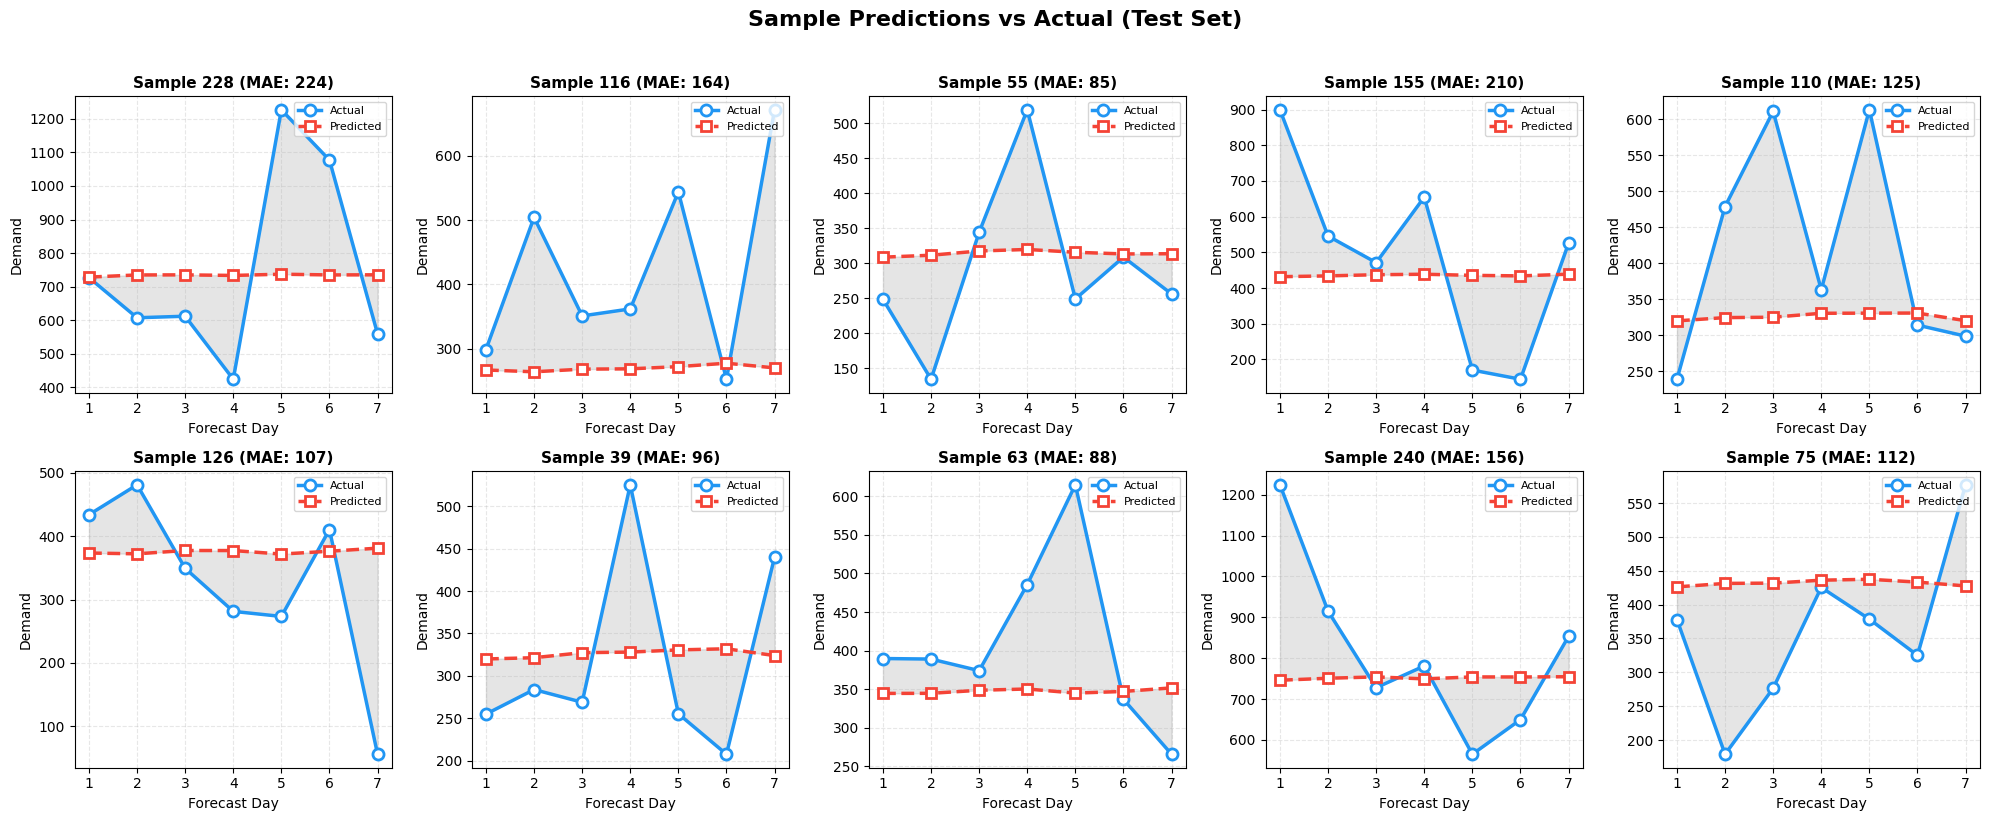

✓ Saved: outputs/predictions_samples.png


In [18]:
# Sample predictions visualization with improved styling
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Predictions vs Actual (Test Set)', fontsize=16, fontweight='bold', y=1.02)

# Set random seed for reproducibility in sample selection
np.random.seed(42)
sample_indices = np.random.choice(len(y_pred), 10, replace=False)

# Calculate global min/max for consistent y-axis
global_min = min(y_true[sample_indices].min(), y_pred[sample_indices].min())
global_max = max(y_true[sample_indices].max(), y_pred[sample_indices].max())
y_margin = (global_max - global_min) * 0.1

for idx, sample_idx in enumerate(sample_indices):
    row, col = idx // 5, idx % 5
    ax = axes[row, col]
    
    days = range(1, FORECAST_HORIZON + 1)
    
    # Plot with improved colors and style
    ax.plot(days, y_true[sample_idx], 'o-', color='#2196F3', label='Actual', 
            linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
    ax.plot(days, y_pred[sample_idx], 's--', color='#F44336', label='Predicted', 
            linewidth=2.5, markersize=7, markerfacecolor='white', markeredgewidth=2)
    
    # Calculate sample MAE
    sample_mae = np.mean(np.abs(y_true[sample_idx] - y_pred[sample_idx]))
    
    ax.set_xlabel('Forecast Day', fontsize=10)
    ax.set_ylabel('Demand', fontsize=10)
    ax.set_title(f'Sample {sample_idx} (MAE: {sample_mae:.0f})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(range(1, FORECAST_HORIZON + 1))
    
    # Add shaded area between actual and predicted
    ax.fill_between(days, y_true[sample_idx], y_pred[sample_idx], alpha=0.2, color='gray')

plt.tight_layout()
plt.savefig('outputs/predictions_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: outputs/predictions_samples.png")

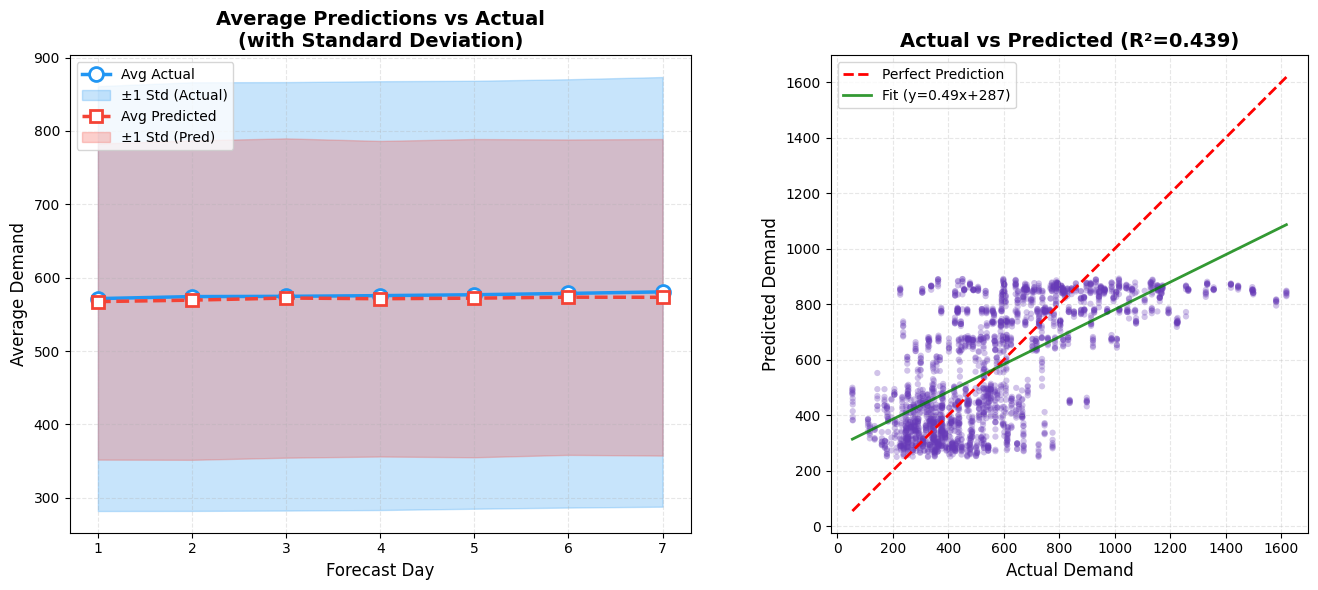

✓ Saved: outputs/avg_predictions.png


In [19]:
# Aggregate predictions vs actual with scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Average predictions over forecast horizon
avg_actual = y_true.mean(axis=0)
avg_pred = y_pred.mean(axis=0)
std_actual = y_true.std(axis=0)
std_pred = y_pred.std(axis=0)

days = range(1, FORECAST_HORIZON + 1)

axes[0].plot(days, avg_actual, 'o-', color='#2196F3', label='Avg Actual', linewidth=2.5, markersize=10, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(days, avg_actual - std_actual, avg_actual + std_actual, alpha=0.25, color='#2196F3', label='±1 Std (Actual)')
axes[0].plot(days, avg_pred, 's--', color='#F44336', label='Avg Predicted', linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(days, avg_pred - std_pred, avg_pred + std_pred, alpha=0.25, color='#F44336', label='±1 Std (Pred)')

axes[0].set_xlabel('Forecast Day', fontsize=12)
axes[0].set_ylabel('Average Demand', fontsize=12)
axes[0].set_title('Average Predictions vs Actual\n(with Standard Deviation)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10, loc='upper left')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_xticks(range(1, FORECAST_HORIZON + 1))

# Right: Scatter plot of all predictions vs actuals
axes[1].scatter(y_true.flatten(), y_pred.flatten(), alpha=0.3, s=20, c='#673AB7', edgecolors='none')
# Add perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
# Add regression line
z = np.polyfit(y_true.flatten(), y_pred.flatten(), 1)
p = np.poly1d(z)
x_line = np.linspace(min_val, max_val, 100)
axes[1].plot(x_line, p(x_line), 'g-', linewidth=2, alpha=0.8, label=f'Fit (y={z[0]:.2f}x+{z[1]:.0f})')

axes[1].set_xlabel('Actual Demand', fontsize=12)
axes[1].set_ylabel('Predicted Demand', fontsize=12)
axes[1].set_title(f'Actual vs Predicted (R²={r2:.3f})', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('outputs/avg_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: outputs/avg_predictions.png")

## 10. Error Distribution Analysis

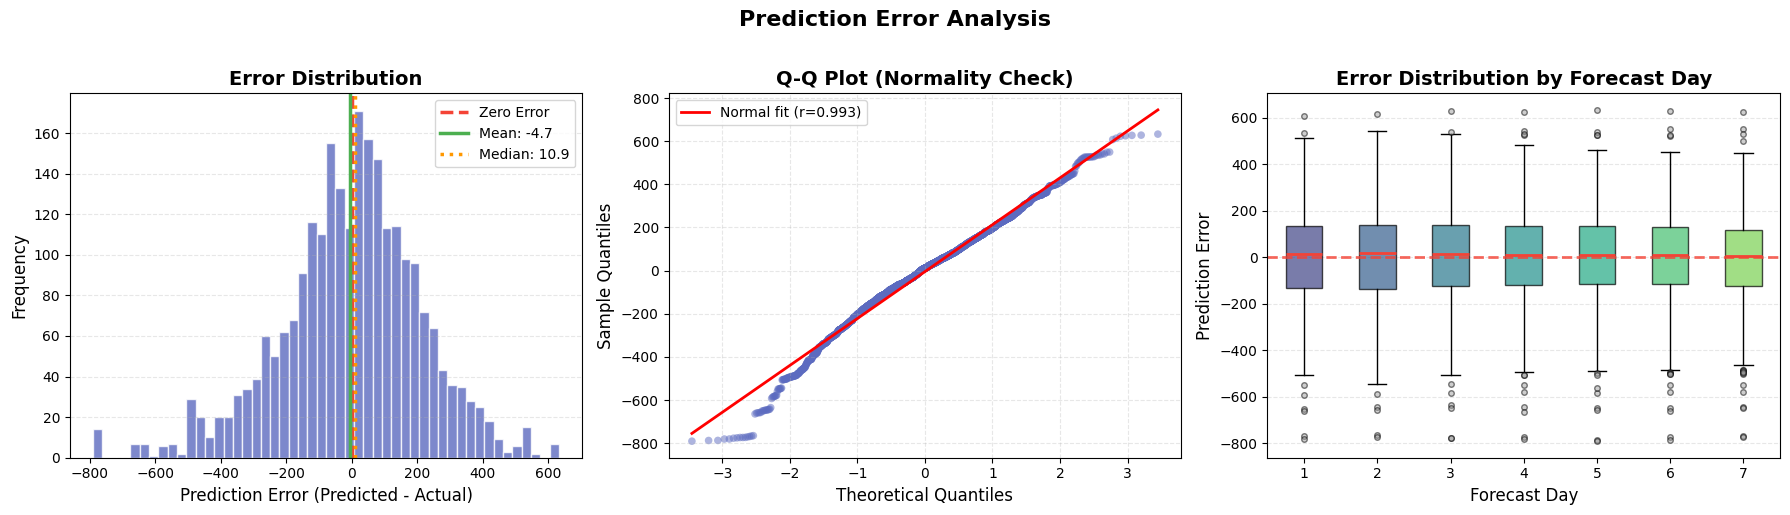

✓ Saved: outputs/error_analysis.png


In [21]:
# Error distribution analysis with improved styling
errors = y_pred - y_true
errors_flat = errors.flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Prediction Error Analysis', fontsize=16, fontweight='bold', y=1.02)

# Histogram of errors with better styling
n, bins, patches = axes[0].hist(errors_flat, bins=50, edgecolor='white', alpha=0.8, color='#5C6BC0')
axes[0].axvline(x=0, color='#F44336', linestyle='--', linewidth=2.5, label='Zero Error')
axes[0].axvline(x=errors_flat.mean(), color='#4CAF50', linestyle='-', linewidth=2.5, label=f'Mean: {errors_flat.mean():.1f}')
axes[0].axvline(x=np.median(errors_flat), color='#FF9800', linestyle=':', linewidth=2.5, label=f'Median: {np.median(errors_flat):.1f}')
axes[0].set_xlabel('Prediction Error (Predicted - Actual)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Error Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--', axis='y')

# QQ plot with improved styling
from scipy import stats
(osm, osr), (slope, intercept, r) = stats.probplot(errors_flat, dist="norm", plot=None)
axes[1].scatter(osm, osr, alpha=0.5, s=30, c='#5C6BC0', edgecolors='none')
axes[1].plot(osm, slope*np.array(osm) + intercept, 'r-', linewidth=2, label=f'Normal fit (r={r:.3f})')
axes[1].set_xlabel('Theoretical Quantiles', fontsize=12)
axes[1].set_ylabel('Sample Quantiles', fontsize=12)
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Box plot by forecast day with improved styling
bp = axes[2].boxplot([errors[:, i] for i in range(FORECAST_HORIZON)], 
                      labels=range(1, FORECAST_HORIZON + 1),
                      patch_artist=True,
                      medianprops=dict(color='#F44336', linewidth=2),
                      flierprops=dict(marker='o', markerfacecolor='#9E9E9E', markersize=4, alpha=0.5))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, FORECAST_HORIZON))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[2].axhline(y=0, color='#F44336', linestyle='--', alpha=0.8, linewidth=2)
axes[2].set_xlabel('Forecast Day', fontsize=12)
axes[2].set_ylabel('Prediction Error', fontsize=12)
axes[2].set_title('Error Distribution by Forecast Day', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('outputs/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: outputs/error_analysis.png")

## 11. Save Model and Summary

In [16]:
# Create outputs directory if it doesn't exist
import os
os.makedirs('outputs', exist_ok=True)

# Save the trained model
model_save_path = 'outputs/lstm_demand_model.pt'
torch.save({
    'model_state_dict': model.state_dict(),
    'input_size': len(FEATURE_COLS),
    'lstm_units_1': LSTM_UNITS_1,
    'lstm_units_2': LSTM_UNITS_2,
    'dense_units': DENSE_UNITS,
    'dropout_rate': DROPOUT_RATE,
    'forecast_horizon': FORECAST_HORIZON,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_scaler_mean': preprocessor.feature_scaler.mean_,
    'feature_scaler_scale': preprocessor.feature_scaler.scale_,
    'target_scaler_mean': preprocessor.target_scaler.mean_,
    'target_scaler_scale': preprocessor.target_scaler.scale_,
}, model_save_path)
print(f"✓ Model saved to: {model_save_path}")

# Print final summary
print("\n" + "="*60)
print("🎉 TRAINING COMPLETE - FINAL SUMMARY")
print("="*60)
print(f"\n📊 Dataset:")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Validation samples: {len(X_val)}")
print(f"   • Test samples: {len(X_test)}")

print(f"\n🏗️ Model Architecture:")
print(f"   • LSTM Layer 1: {LSTM_UNITS_1} units")
print(f"   • LSTM Layer 2: {LSTM_UNITS_2} units")
print(f"   • Dense Layer: {DENSE_UNITS} units")
print(f"   • Dropout: {DROPOUT_RATE}")
print(f"   • Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\n📈 Performance (Test Set):")
print(f"   • MSE: {mse:.4f}")
print(f"   • RMSE: {rmse:.4f}")
print(f"   • MAE: {mae:.4f}")
print(f"   • MAPE: {mape:.2f}%")
print(f"   • R² Score: {r2:.4f}")

print(f"\n📁 Outputs saved to: ./outputs/")
print("="*60)

✓ Model saved to: outputs/lstm_demand_model.pt

🎉 TRAINING COMPLETE - FINAL SUMMARY

📊 Dataset:
   • Training samples: 2464
   • Validation samples: 704
   • Test samples: 352

🏗️ Model Architecture:
   • LSTM Layer 1: 64 units
   • LSTM Layer 2: 32 units
   • Dense Layer: 16 units
   • Dropout: 0.2
   • Total Parameters: 35,975

📈 Performance (Test Set):
   • MSE: 47759.2969
   • RMSE: 218.5390
   • MAE: 167.1259
   • MAPE: 38.41%
   • R² Score: 0.4391

📁 Outputs saved to: ./outputs/
